## Source coverage

| Original MATLAB file | This notebook |
| --- | --- |
| `main.m` | end-to-end walkthrough and validation cells |
| `functions/naive_aoa.m` | `naive_aoa_ch3(...)` |
| `functions/naive_tof.m` | `naive_tof_ch3(...)` |
| `functions/naive_spectrum.m` | `naive_spectrum_ch3(...)` |

## Goal

Take a raw CSI tensor shaped like `[T, S, A, L]` and extract three interpretable features:

1. AoA-like direction estimate
2. ToF-like delay estimate
3. STFT spectrum for motion analysis

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import numpy as np

CACHE_DIR = Path.cwd() / ".cache"
CACHE_DIR.mkdir(exist_ok=True)

os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))

MPL_CACHE_DIR = Path.cwd() / ".matplotlib"
MPL_CACHE_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

'/Users/doanvankhoan/Desktop/wifi-sensing-learning/chapter3chapter/notebooks/.matplotlib'

In [2]:
try:
    import matplotlib
    try:
        from IPython import get_ipython
    except Exception:
        get_ipython = None

    ip = get_ipython() if get_ipython is not None else None

    if ip is None:
        matplotlib.use("Agg")
    else:
        try:
            ip.run_line_magic("matplotlib", "inline")
        except:
            pass

    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True

except Exception:
    MATPLOTLIB_AVAILABLE = False

Matplotlib is building the font cache; this may take a moment.


In [3]:
from scipy.io import loadmat
from scipy.signal import stft as scipy_stft

In [9]:
SRC_MAT = Path("../data/csi_src_test.mat")
FEATURE_MAT = Path("../data/csi_feature_test.mat")

In [10]:
print("Matplotlib available:", MATPLOTLIB_AVAILABLE)
print("Source mat exists:", SRC_MAT.exists())
print("Feature mat exists:", FEATURE_MAT.exists())

Matplotlib available: True
Source mat exists: True
Feature mat exists: True


## Load the shipped sample files

The repo already gives us:
- `csi_src_test.mat`: raw CSI input
- `csi_feature_test.mat`: reference outputs produced by the MATLAB script

In [11]:
src_data = loadmat(SRC_MAT)
feature_data = loadmat(FEATURE_MAT)

for label, payload in [("src_data", src_data), ("feature_data", feature_data)]:
    print(label)
    for key, value in payload.items():
        if not key.startswith("__"):
            print(" ", key, getattr(value, "shape", None), getattr(value, "dtype", None))
    
    print()

src_data
  csi (999, 57, 3, 2) complex128

feature_data
  aoa_mat (3, 999) float64
  stft_mat (128, 28) complex128
  tof_mat (999, 3) float64



In [12]:
csi_src = src_data["csi"]
aoa_ref = feature_data["aoa_mat"]
tof_ref = feature_data["tof_mat"]
stft_ref = feature_data["stft_mat"]

print("csi_src shape:", csi_src.shape)
print("aoa_ref shape:", aoa_ref.shape)
print("tof_ref shape:", tof_ref.shape)
print("stft_ref shape:", stft_ref.shape)

csi_src shape: (999, 57, 3, 2)
aoa_ref shape: (3, 999)
tof_ref shape: (999, 3)
stft_ref shape: (128, 28)


## Tensor convention

This chapter assumes CSI is a 4D tensor with shape `[T, S, A, L]`:

- `T`: packets or time samples
- `S`: subcarriers
- `A`: antennas
- `L`: repeated training symbols or extra slices

For the sample file, the actual shape is:

In [13]:
T, S, A, L = csi_src.shape
print(
    {
        "T": T,
        "S": S,
        "A": A,
        "L": L
    }
)

{'T': 999, 'S': 57, 'A': 3, 'L': 2}


## Constants from `main.m`

We keep the same constants used in the MATLAB code.

In [15]:
C = 299_792_458.0
BW = 20e6
SUBCARRIER_FREQ = np.linspace(5.8153e9, 5.8347e9, 57)
SUBCARRIER_LAMBDA = C / SUBCARRIER_FREQ

In [16]:
ANTENNA_LOC = np.array([
    [0.0, 0.0514665, 0.0],
    [0.0, 0.0, 0.0514665],
    [0.0, 0.0, 0.0],
])

In [17]:
LINEAR_INTERVAL = np.arange(19, 38)

In [18]:
print("Center wavelength range (m):", SUBCARRIER_LAMBDA.min(), "to", SUBCARRIER_LAMBDA.max())

Center wavelength range (m): 0.0513809549762627 to 0.05155236324867161


## Shared helpers

We use a small NumPy STFT helper so the whole notebook remains self-contained and deterministic.

In [19]:
def hamming_window(n: int) -> np.ndarray:
    if n <= 1:
        return np.ones((n,), dtype=float)
    idx = np.arange(n)
    return 0.54 - 0.46 * np.cos(2 * np.pi * idx / (n - 1))


def stft_numpy(x: np.ndarray, sample_rate: float, window_size: int | None = None, overlap: int | None = None):
    x = np.asarray(x)
    if x.ndim == 0:
        x = x.reshape(1)
    else:
        x = x.reshape(-1)
    T = int(x.size)
    if T == 0:
        raise ValueError("Input signal must not be empty")

    if window_size is None:
        window_size = int(min(T, 128))
    else:
        window_size = int(window_size)

    if overlap is None:
        overlap = int(round(window_size / 2))
    else:
        overlap = int(overlap)

    hop = int(max(1, window_size - overlap))
    window = hamming_window(window_size)

    frames = []
    times = []
    for start in range(0, max(T - window_size + 1, 1), hop):
        frame = np.zeros(window_size, dtype=complex)
        cur = x[start:start + window_size]
        frame[: len(cur)] = cur
        frame = frame * window
        frames.append(np.fft.fft(frame))
        times.append(start / sample_rate)

    zxx = np.stack(frames, axis=1)
    freqs = np.fft.fftfreq(window_size, d=1.0 / sample_rate)
    order = np.argsort(freqs)
    return zxx[order], freqs[order], np.array(times)


def show_spectrum(freqs: np.ndarray, times: np.ndarray, zxx: np.ndarray, title: str):
    if not MATPLOTLIB_AVAILABLE:
        print("Matplotlib not available, skipping plot")
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.pcolormesh(times, freqs, np.abs(zxx), shading="auto")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    fig.tight_layout()
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    return fig

## Port: `naive_aoa.m`

This estimates an AoA-like direction vector from phase differences between antennas.

In [20]:
def naive_aoa_ch3(csi_data: np.ndarray, antenna_loc: np.ndarray, est_rco: np.ndarray, subcarrier_lambda: np.ndarray = SUBCARRIER_LAMBDA) -> np.ndarray:
    csi_phase = np.unwrap(np.angle(csi_data), axis=1)
    ant_diff = antenna_loc[:, 1:] - antenna_loc[:, [0]]
    ant_diff_length = np.linalg.norm(ant_diff, axis=0)
    ant_diff_normalize = ant_diff / ant_diff_length

    ref_phase = csi_phase[:, :, [0], :]
    phase_diff = csi_phase[:, :, 1:, :] - ref_phase - est_rco[1:].reshape(1, 1, -1, 1)
    phase_diff = np.unwrap(phase_diff, axis=1)
    phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi

    cos_mat = subcarrier_lambda.reshape(1, -1, 1, 1) * phase_diff / (2 * np.pi * ant_diff_length.reshape(1, 1, -1, 1))
    cos_mat_mean = np.mean(cos_mat, axis=(1, 3))
    aoa_mat_sol = np.linalg.lstsq(ant_diff_normalize.T, cos_mat_mean.T, rcond=None)[0]

    invalid_dim = np.where(np.isclose(ant_diff_normalize.sum(axis=1), 0))[0]
    valid_dim = np.array([i for i in range(3) if i not in invalid_dim])
    if len(invalid_dim) > 0:
        remain = 1 - np.sum(aoa_mat_sol[valid_dim, :] ** 2, axis=0)
        remain = np.clip(remain, 0, None)
        fill = np.sqrt(remain / len(invalid_dim))
        for idx in invalid_dim:
            aoa_mat_sol[idx, :] = fill

    return aoa_mat_sol

## Port: `naive_tof.m`

This turns CFR into CIR by IFFT and uses the peak location as a rough ToF estimate.

In [22]:
def naive_tof_ch3(csi_data: np.ndarray, bw_hz: float = BW) -> np.ndarray:
    subcarrier_num = csi_data.shape[1]
    ifft_point = 2 ** int(np.ceil(np.log2(subcarrier_num)))
    cir_sequence = np.fft.ifft(csi_data, n=ifft_point, axis=1)
    cir_sequence = np.mean(cir_sequence, axis=3)
    half_point = ifft_point // 2
    half_sequence = cir_sequence[:, :half_point, :]
    peak_indices = np.abs(half_sequence).argmax(axis=1)
    # MATLAB `max` returns 1-based indices, so add 1 here to match the shipped reference .mat file.
    tof_mat = (peak_indices + 1) * subcarrier_num / (ifft_point * bw_hz)
    return tof_mat

## Port: `naive_spectrum.m`

This chapter's MATLAB code builds a 1D power-like trace from CSI and then applies STFT.

In [23]:
def naive_spectrum_ch3(csi_data: np.ndarray, sample_rate: float, visible: bool = False):
    power_trace = np.mean(csi_data * np.conj(csi_data), axis=(1, 2, 3))
    freqs, times, zxx = scipy_stft(
        np.real(power_trace),
        fs=sample_rate,
        window='hann',
        nperseg=128,
        noverlap=96,
        nfft=128,
        return_onesided=False,
        boundary=None,
        padded=False,
    )
    zxx = np.fft.fftshift(zxx, axes=0)
    freqs = np.fft.fftshift(freqs)
    if visible:
        show_spectrum(freqs, times, zxx, "Chapter 3 STFT spectrum")
    return zxx, freqs, times

In [33]:
def phase_sensitive_trace_ch3(csi_data: np.ndarray, antenna_a: int = 0, antenna_b: int = 1) -> np.ndarray:
    pair_trace = np.mean(csi_data[:, :, antenna_a, :] * np.conj(csi_data[:, :, antenna_b, :]), axis=2)
    phase_trace = np.mean(np.unwrap(np.angle(pair_trace), axis=1), axis=1)
    phase_trace = phase_trace - np.mean(phase_trace)
    return np.real(phase_trace)

In [34]:
def phase_sensitive_spectrum_ch3(csi_data: np.ndarray, sample_rate: float, antenna_a: int = 0, antenna_b: int = 1, visible: bool = False):
    phase_trace = phase_sensitive_trace_ch3(csi_data, antenna_a=antenna_a, antenna_b=antenna_b)
    freqs, times, zxx = scipy_stft(
        phase_trace,
        fs=sample_rate,
        window='hann',
        nperseg=128,
        noverlap=96,
        nfft=128,
        return_onesided=False,
        boundary=None,
        padded=False,
    )
    zxx = np.fft.fftshift(zxx, axes=0)
    freqs = np.fft.fftshift(freqs)
    if visible:
        show_spectrum(freqs, times, zxx, 'Chapter 3 phase-sensitive STFT')
    return phase_trace, zxx, freqs, times

## Reproduce `main.m`

We now run the exact same high-level flow as the MATLAB script:

1. load raw CSI
2. estimate AoA
3. estimate ToF
4. generate STFT spectrum
5. compare against the shipped reference `.mat` file

In [24]:
aoa_py = naive_aoa_ch3(csi_src, ANTENNA_LOC, np.zeros((3, 1)))
tof_py = naive_tof_ch3(csi_src)
stft_py, stft_freqs, stft_times = naive_spectrum_ch3(csi_src, sample_rate=50, visible=False)

print("aoa_py shape:", aoa_py.shape)
print("tof_py shape:", tof_py.shape)
print("stft_py shape:", stft_py.shape)

aoa_py shape: (3, 999)
tof_py shape: (999, 3)
stft_py shape: (128, 28)


In [36]:
phase_trace_py, phase_stft_py, phase_stft_freqs, phase_stft_times = phase_sensitive_spectrum_ch3(
    csi_src, sample_rate=50, antenna_a=0, antenna_b=1, visible=False
)

In [37]:
print("phase_trace_py shape:", phase_trace_py.shape)
print("phase_stft_py shape:", phase_stft_py.shape)

phase_trace_py shape: (999,)
phase_stft_py shape: (128, 28)


In [25]:
aoa_gt = np.array([[0.0], [0.0], [1.0]])
cosine_scores = np.sum(aoa_gt * aoa_py, axis=0)
cosine_scores = np.clip(cosine_scores, -1.0, 1.0)
angle_error = np.mean(np.arccos(cosine_scores))

est_dist = np.mean(tof_py * C)

print("Angle estimation error (rad):", float(angle_error))
print("Ground truth distance: 10 m")
print("Estimated distance (m):", float(est_dist))

Angle estimation error (rad): 0.16197279523710809
Ground truth distance: 10 m
Estimated distance (m): 13.350132895312502


## Compare against the shipped MATLAB outputs

This is the most useful validation cell in the notebook.
It tells us how close the Python port is to the provided `.mat` outputs.

In [26]:
print("AoA max abs diff:", float(np.max(np.abs(aoa_py - aoa_ref))))
print("AoA mean abs diff:", float(np.mean(np.abs(aoa_py - aoa_ref))))
print("ToF max abs diff:", float(np.max(np.abs(tof_py - tof_ref))))
print("ToF mean abs diff:", float(np.mean(np.abs(tof_py - tof_ref))))
print("STFT shape python vs ref:", stft_py.shape, stft_ref.shape)
print("STFT max abs diff:", float(np.max(np.abs(stft_py - stft_ref))))
print("STFT mean abs diff:", float(np.mean(np.abs(stft_py - stft_ref))))

stft_py_norm = np.abs(stft_py) / (np.max(np.abs(stft_py)) + 1e-12)
stft_ref_norm = np.abs(stft_ref) / (np.max(np.abs(stft_ref)) + 1e-12)
print("STFT normalized max abs diff:", float(np.max(np.abs(stft_py_norm - stft_ref_norm))))
print("STFT normalized mean abs diff:", float(np.mean(np.abs(stft_py_norm - stft_ref_norm))))
print("STFT normalized magnitude corrcoef:", float(np.corrcoef(stft_py_norm.ravel(), stft_ref_norm.ravel())[0, 1]))

AoA max abs diff: 3.7470027081099033e-16
AoA mean abs diff: 2.3634377367729392e-17
ToF max abs diff: 0.0
ToF mean abs diff: 0.0
STFT shape python vs ref: (128, 28) (128, 28)
STFT max abs diff: 7118026.039429837
STFT mean abs diff: 114880.35214293755
STFT normalized max abs diff: 0.5000479339513164
STFT normalized mean abs diff: 0.0157866215685676
STFT normalized magnitude corrcoef: 0.6595065209987372


## Visualize the outputs

These plots make the three features more interpretable.

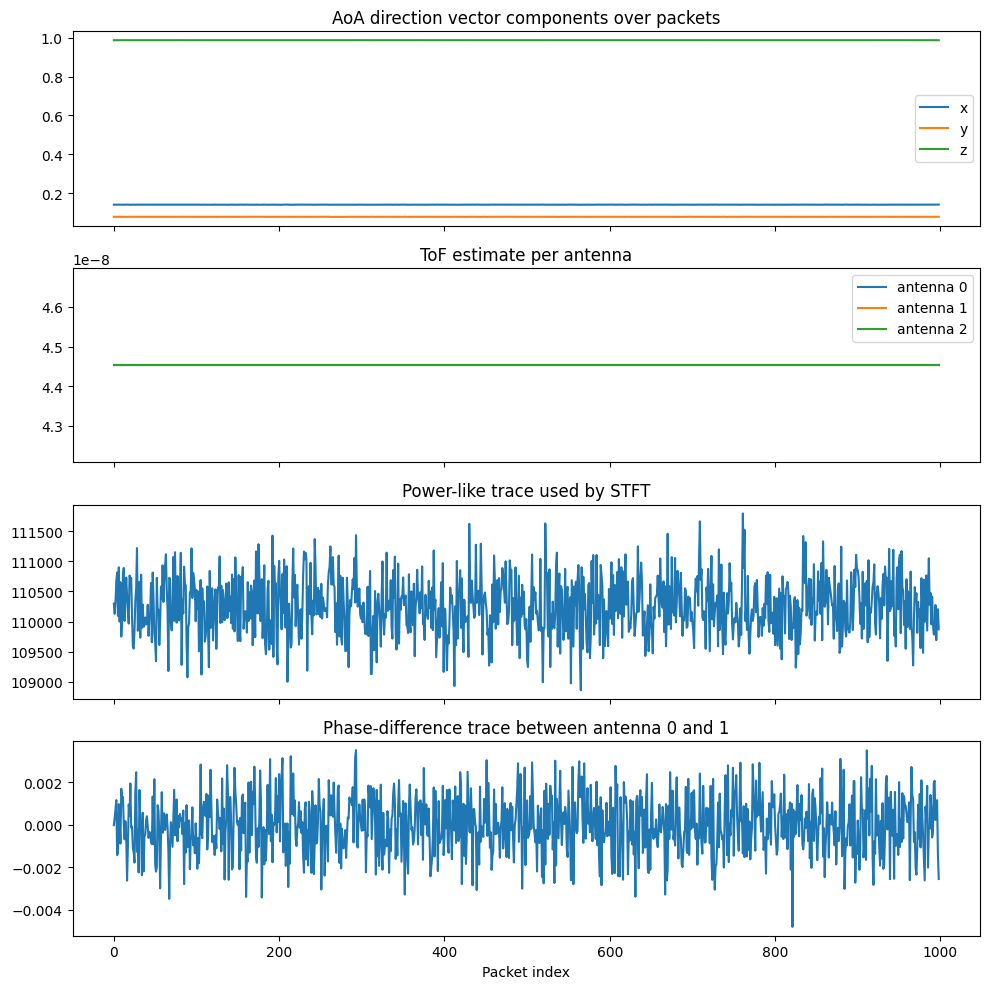

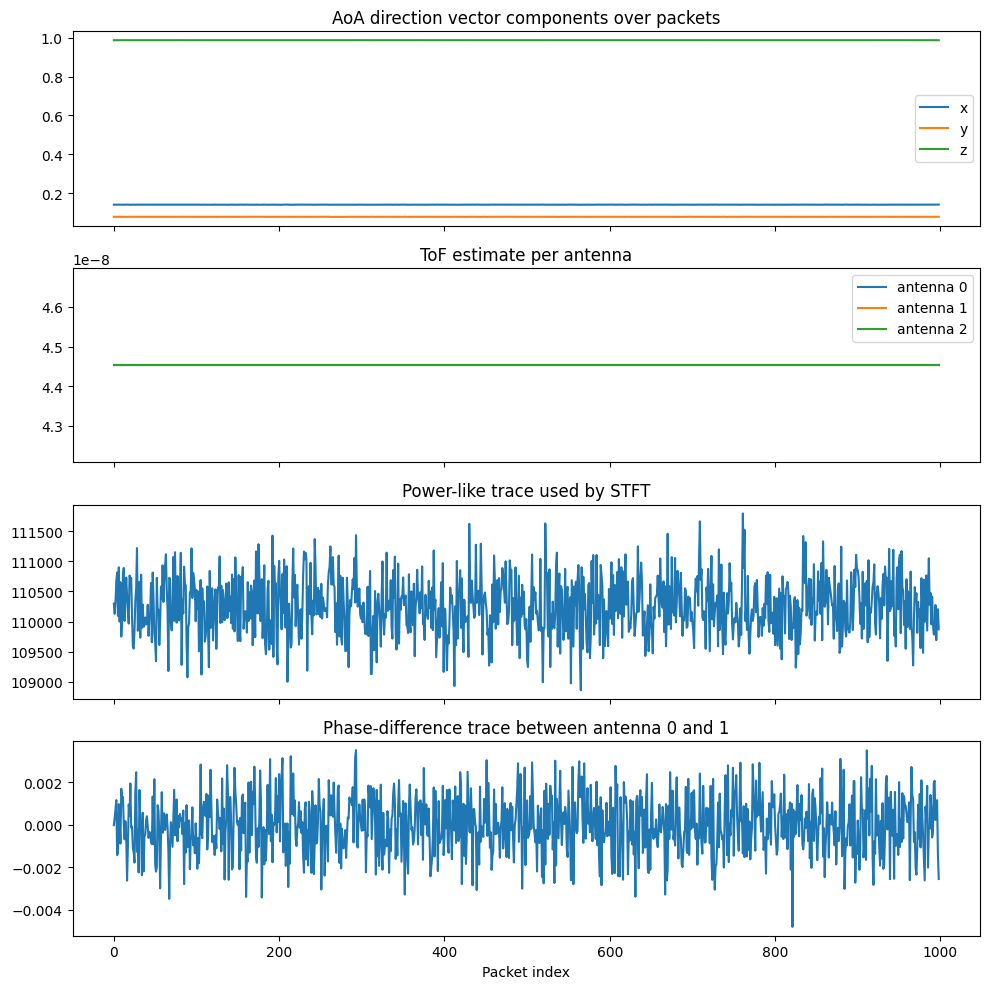

In [38]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(aoa_py[0], label='x')
    axes[0].plot(aoa_py[1], label='y')
    axes[0].plot(aoa_py[2], label='z')
    axes[0].set_title('AoA direction vector components over packets')
    axes[0].legend()

    axes[1].plot(tof_py[:, 0], label='antenna 0')
    axes[1].plot(tof_py[:, 1], label='antenna 1')
    axes[1].plot(tof_py[:, 2], label='antenna 2')
    axes[1].set_title('ToF estimate per antenna')
    axes[1].legend()

    axes[2].plot(np.real(np.mean(csi_src * np.conj(csi_src), axis=(1, 2, 3))))
    axes[2].set_title('Power-like trace used by STFT')

    axes[3].plot(phase_trace_py)
    axes[3].set_title('Phase-difference trace between antenna 0 and 1')
    axes[3].set_xlabel('Packet index')


    fig.tight_layout()
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
else:
    print('Matplotlib not available, skipping line plots')

**AoA direction vector components over packets:**

-Trục ngang: packet index
-Tức là packet CSI thứ 1, 2, 3, ...
-Trục dọc: giá trị các thành phần của vector hướng AoA
    -đường x: thành phần theo trục x
    -đường y: thành phần theo trục y
    -đường z: thành phần theo trục z


**ToF estimate per antenna:**

-Trục ngang: packet index
-Trục dọc: ToF estimate theo giây
    -Trong hình có 1e-8, nghĩa là giá trị đang ở cỡ 10^-8 s
-Mỗi đường là một antenna:
    -antenna 0
    -antenna 1
    -antenna 2


**Power-like trace used by STFT:**

-Trục ngang: packet index
-Trục dọc: giá trị power-like trace
    -Đây là tín hiệu 1D được tạo từ:
> mean(csi * conj(csi), axis=(1,2,3))

$\rightarrow$ nên nó gần giống “năng lượng CSI trung bình” của mỗi packet

**Phase-difference trace between antenna 0 and 1:**

-Trục ngang: packet index
-Trục dọc: phase-difference trace

$\rightarrow$ Tức là độ lệch pha trung bình giữa antenna 0 và antenna 1 theo thời gian

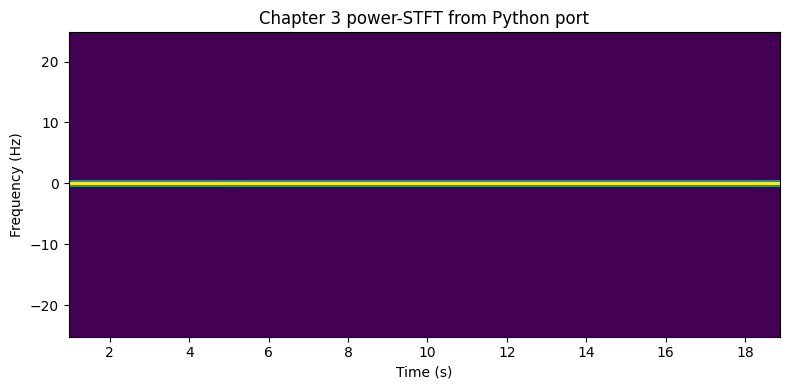

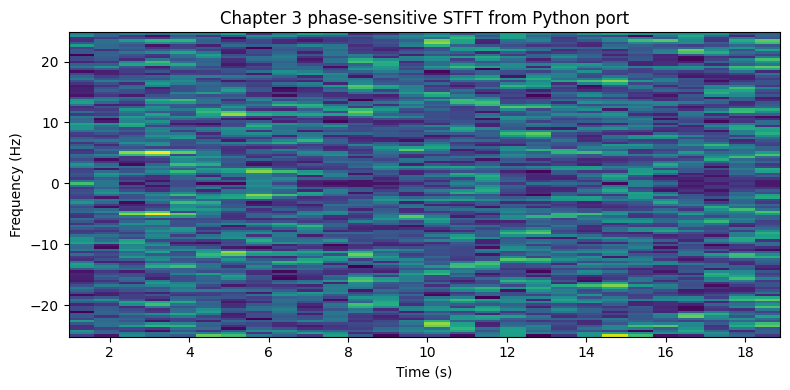

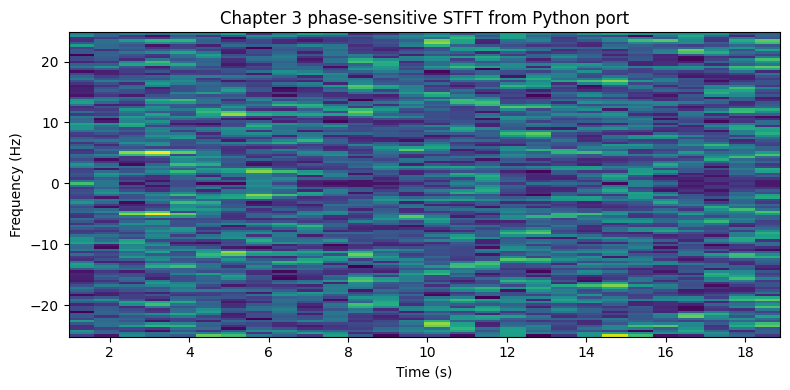

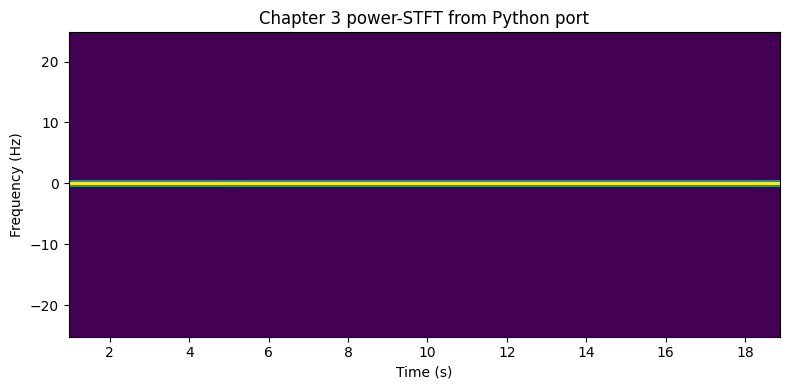

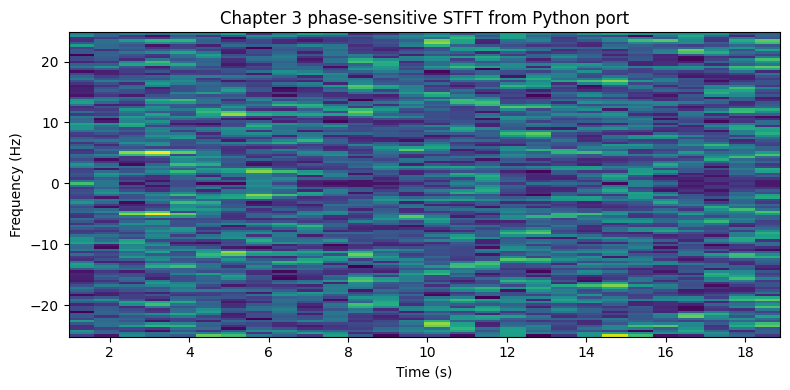

In [39]:
show_spectrum(stft_freqs, stft_times, stft_py, 'Chapter 3 power-STFT from Python port')
show_spectrum(phase_stft_freqs, phase_stft_times, phase_stft_py, 'Chapter 3 phase-sensitive STFT from Python port')

**Chapter 3 power-STFT from Python port:**

-Trục ngang: Time (s)
$\rightarrow$ Đây là thời gian của các cửa sổ STFT

-Trục dọc: Frequency (Hz)
$\rightarrow$ Đây là tần số Doppler-like / temporal frequency của tín hiệu 1D đầu vào

-Màu sắc: độ lớn phổ |STFT|
$\rightarrow$ Sáng hơn = năng lượng mạnh hơn


**Chapter 3 phase-sensitive STFT from Python port:**

-Trục ngang: Time (s)
-Trục dọc: Frequency (Hz)
-Màu sắc: độ lớn phổ |STFT|

$\rightarrow$ Nhưng lần này STFT lấy từ phase trace, nên nhạy hơn với thay đổi pha giữa antenna

## Read the shipped STFT side by side

The reference `.mat` already contains `stft_mat`, so we can compare magnitude patterns visually.

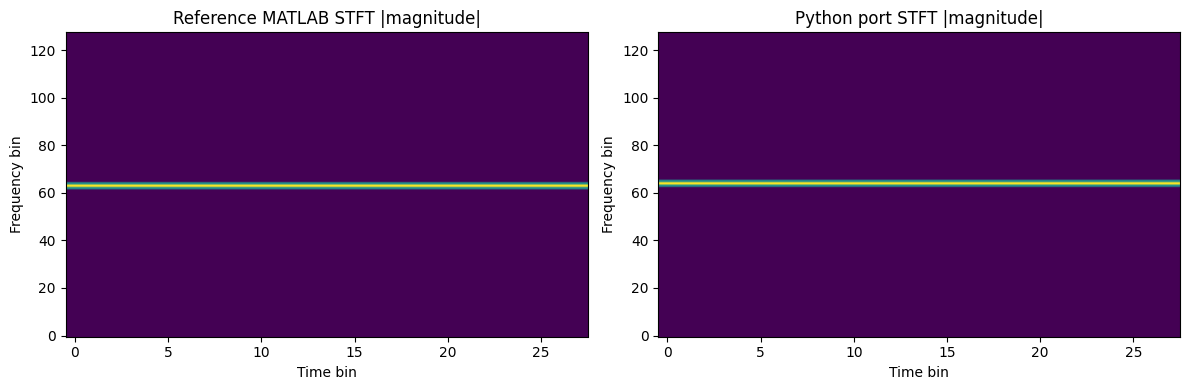

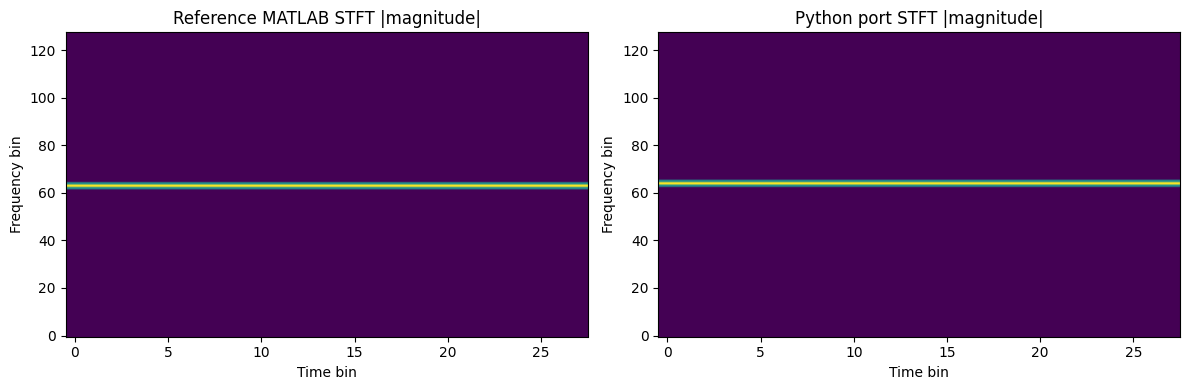

In [40]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(np.abs(stft_ref), aspect='auto', origin='lower')
    axes[0].set_title('Reference MATLAB STFT |magnitude|')
    axes[0].set_xlabel('Time bin')
    axes[0].set_ylabel('Frequency bin')

    axes[1].imshow(np.abs(stft_py), aspect='auto', origin='lower')
    axes[1].set_title('Python port STFT |magnitude|')
    axes[1].set_xlabel('Time bin')
    axes[1].set_ylabel('Frequency bin')

    fig.tight_layout()
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
else:
    print('Matplotlib not available, skipping STFT comparison')

## What to take away from chapter 3

This chapter is valuable because the extracted features are still interpretable:

- AoA comes from inter-antenna phase geometry
- ToF comes from CIR peak location after IFFT
- STFT comes from turning CSI into a time-frequency trace

This is the bridge between raw CSI and later AI models.